<h1>Training<h1>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [7]:
from pathlib import Path
import pandas as pd

ROOT = Path("..").resolve()          # notebook inside notebooks/
DATA_DIR = ROOT / "data"
ART_DIR  = ROOT / "artifacts"

DATA_DIR.mkdir(exist_ok=True)
ART_DIR.mkdir(exist_ok=True)

INPUT_RELEVANT = DATA_DIR / "hn_market_relevant_latest.csv"
SCORED_OUT     = DATA_DIR / "hn_scored_latest.csv"

KMEANS_PATH    = ART_DIR / "kmeans_model.joblib"
TFIDF_PATH     = ART_DIR / "tfidf_vectorizer.joblib"
CLUSTER_MAP    = ART_DIR / "cluster_name_map.json"

# Additional outputs (recommended)
INSIGHTS_OUT = DATA_DIR / "insights_latest.csv"
QUOTES_OUT   = DATA_DIR / "quotes_latest.csv"
THEME_KEYWORDS_OUT = DATA_DIR / "theme_keywords_latest.csv"

In [8]:
df_relevant = pd.read_csv(INPUT_RELEVANT)

df_relevant.shape, df_relevant.columns
df_relevant["clean_length"].describe()
df_relevant["keyword"].value_counts().head(10)
df_relevant[["keyword","story_title","clean_text"]].head(3)

,keyword,story_title,clean_text
0,film,Show HN: CLI for agentic activity tracking in ...,"Hey hackers, I made a CLI to sync your Codex p..."
1,film,Ask HN: Orbis. Your AI Co-Founder (Waitlist Open),Most AI tools bolt onto your workflow. Orbis l...
2,film,Show HN: APA citation generator that explains ...,I built this because many citation tools retur...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_relevant["clean_text"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=6000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(texts)
X.shape

(1642, 6000)

In [10]:
from sklearn.cluster import KMeans

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df_relevant["cluster"] = kmeans.fit_predict(X)

df_relevant["cluster"].value_counts()

/opt/anaconda3/envs/shid_env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/shid_env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/shid_env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


cluster
2    380
3    298
1    281
4    204
5    177
6    146
7     82
0     74
Name: count, dtype: int64

In [11]:
import numpy as np

terms = np.array(vectorizer.get_feature_names_out())
centroids = kmeans.cluster_centers_

cluster_labels = {}

for i in range(k):
    top_terms = terms[centroids[i].argsort()[::-1][:8]]
    cluster_labels[i] = ", ".join(top_terms)

df_relevant["cluster_label"] = df_relevant["cluster"].map(cluster_labels)

df_relevant[["cluster","cluster_label"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_label
70,0,"social, media, social media, platforms, conten..."
143,1,"monetization, ads, platform, like, google, jus..."
34,2,"just, monetization, think, people, like, good,..."
1,3,"ai, built, data, tools, feedback, hn, building..."
0,4,"agent, agents, github, code, https, com, ai, g..."
14,5,"people, software, want, open, open source, sou..."
9,6,"app, feedback, users, monetization, game, feat..."
55,7,"video, youtube, content, videos, creators, tik..."


In [12]:
CLUSTER_NAME_MAP = {
    0: "Pricing & Monetization Concerns",
    1: "Early Product Feedback & Tool Discovery",
    2: "Platform Perception & Social Sentiment",
    3: "Ad-Based Monetization Trade-offs",
    4: "Developer Ecosystem & Integrations",
    5: "AI Content Platforms & Automation",
    6: "Creator Economy & AI Disruption",
    7: "Open Platform & Trust Signals"
}

df_relevant["market_theme"] = df_relevant["cluster"].map(CLUSTER_NAME_MAP)

In [13]:
df_relevant["market_theme"].value_counts()

market_theme
Platform Perception & Social Sentiment     380
Ad-Based Monetization Trade-offs           298
Early Product Feedback & Tool Discovery    281
Developer Ecosystem & Integrations         204
AI Content Platforms & Automation          177
Creator Economy & AI Disruption            146
Open Platform & Trust Signals               82
Pricing & Monetization Concerns             74
Name: count, dtype: int64

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def top_keywords_by_theme(df, text_col="clean_text", theme_col="market_theme", top_n=10, min_df=3):
    out = []
    for theme, g in df.dropna(subset=[theme_col, text_col]).groupby(theme_col):
        texts = g[text_col].astype(str).tolist()

        vec = TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            min_df=min_df,
            max_features=5000
        )
        X = vec.fit_transform(texts)
        terms = np.array(vec.get_feature_names_out())
        scores = np.asarray(X.mean(axis=0)).ravel()

        top_idx = scores.argsort()[::-1][:top_n]
        out.append({
            "market_theme": theme,
            "top_keywords": ", ".join(terms[top_idx])
        })
    return pd.DataFrame(out).sort_values("market_theme")

theme_keywords = top_keywords_by_theme(df_relevant, top_n=12, min_df=2)
theme_keywords

,market_theme,top_keywords
0,AI Content Platforms & Automation,"people, open, software, want, like, just, sour..."
1,Ad-Based Monetization Trade-offs,"ai, built, data, tools, just, https, like, fre..."
2,Creator Economy & AI Disruption,"app, users, monetization, game, feedback, http..."
3,Developer Ecosystem & Integrations,"agent, agents, ai, https, code, github, com, c..."
4,Early Product Feedback & Tool Discovery,"monetization, platform, like, just, ads, googl..."
5,Open Platform & Trust Signals,"video, content, youtube, videos, ai, just, mon..."
6,Platform Perception & Social Sentiment,"just, monetization, like, people, platform, th..."
7,Pricing & Monetization Concerns,"social, media, social media, platforms, like, ..."


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def representative_quotes(df, text_col="clean_text", theme_col="market_theme", n_quotes=5, min_len=80):
    results = []

    for theme, g in df.dropna(subset=[theme_col, text_col]).groupby(theme_col):
        g = g.copy()
        g = g[g[text_col].astype(str).str.len() >= min_len]
        if len(g) == 0:
            continue

        vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=8000)
        X = vec.fit_transform(g[text_col].astype(str).tolist())

        centroid = np.asarray(X.mean(axis=0))  # avoid np.matrix issues
        sims = cosine_similarity(X, centroid)
        top_idx = np.argsort(sims.ravel())[::-1][:n_quotes]

        for rank, i in enumerate(top_idx, start=1):
            row = g.iloc[i]
            results.append({
                "market_theme": theme,
                "rank": rank,
                "keyword": row.get("keyword"),
                "story_title": row.get("story_title"),
                "author": row.get("author"),
                "url": row.get("url"),
                "objectID": row.get("objectID"),   # ✅ ADD THIS
                "clean_text": row.get(text_col),
            })

    return pd.DataFrame(results).sort_values(["market_theme", "rank"])

quotes_df = representative_quotes(df_relevant, n_quotes=5)

In [16]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

def theme_stats(df):
    tmp = df.copy()
    tmp["created_at"] = pd.to_datetime(tmp["created_at"], errors="coerce", utc=True)

    stats = (
        tmp.groupby("market_theme")
           .agg(
               mentions=("clean_text", "count"),
               newest=("created_at", "max"),
               oldest=("created_at", "min"),
               unique_authors=("author", "nunique")
           )
           .reset_index()
    )
    stats["days_span"] = (stats["newest"] - stats["oldest"]).dt.days
    stats = stats.sort_values("mentions", ascending=False)
    return stats

def top_signal_phrases(df, theme, text_col="clean_text", top_k=8):
    g = df[df["market_theme"] == theme].copy()
    texts = g[text_col].astype(str).tolist()
    if len(texts) < 3:
        return []

    vec = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=2,
        max_features=8000
    )
    X = vec.fit_transform(texts)
    terms = np.array(vec.get_feature_names_out())

    # average TF-IDF score per term inside this theme
    mean_scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = np.argsort(mean_scores)[::-1][:top_k]
    return terms[top_idx].tolist()

def top_keywords_for_theme(df, theme, n=3):
    vals = df.loc[df["market_theme"] == theme, "keyword"].dropna().astype(str).tolist()
    if not vals:
        return []
    return [k for k, _ in Counter(vals).most_common(n)]

def build_theme_insights(df_relevant, quotes_df, top_phrases_k=8, top_quotes_k=3):
    stats = theme_stats(df_relevant)

    rows = []
    for _, r in stats.iterrows():
        theme = r["market_theme"]

        phrases = top_signal_phrases(df_relevant, theme, top_k=top_phrases_k)
        top_keys = top_keywords_for_theme(df_relevant, theme, n=3)

        q = quotes_df[quotes_df["market_theme"] == theme].sort_values("rank").head(top_quotes_k)

        # 1–2 sentence auto-insight (template-based, repeatable)
        insight = (
            f"Conversation clusters around {', '.join(phrases[:4]) if phrases else 'recurring product/market themes'}. "
            f"Most mentions appear under keywords: {', '.join(top_keys) if top_keys else 'N/A'}."
        )

        rows.append({
            "market_theme": theme,
            "mentions": int(r["mentions"]),
            "unique_authors": int(r["unique_authors"]),
            "newest": r["newest"],
            "days_span": r["days_span"],
            "top_signal_phrases": ", ".join(phrases),
            "insight_summary": insight,
            "quote_1": q.iloc[0]["clean_text"] if len(q) > 0 else "",
            "quote_1_title": q.iloc[0]["story_title"] if len(q) > 0 else "",
            "quote_1_url": q.iloc[0]["url"] if len(q) > 0 else "",
            "quote_2": q.iloc[1]["clean_text"] if len(q) > 1 else "",
            "quote_2_title": q.iloc[1]["story_title"] if len(q) > 1 else "",
            "quote_2_url": q.iloc[1]["url"] if len(q) > 1 else "",
            "quote_3": q.iloc[2]["clean_text"] if len(q) > 2 else "",
            "quote_3_title": q.iloc[2]["story_title"] if len(q) > 2 else "",
            "quote_3_url": q.iloc[2]["url"] if len(q) > 2 else "",
        })

    return pd.DataFrame(rows).sort_values("mentions", ascending=False).reset_index(drop=True)

insights_df = build_theme_insights(df_relevant, quotes_df, top_phrases_k=8, top_quotes_k=3)
insights_df.head(10)

,market_theme,mentions,unique_authors,newest,days_span,top_signal_phrases,insight_summary,quote_1,quote_1_title,quote_1_url,quote_2,quote_2_title,quote_2_url,quote_3,quote_3_title,quote_3_url
0,Platform Perception & Social Sentiment,380,357,2026-02-26 08:57:08+00:00,1321,"just, monetization, like, people, platform, th...","Conversation clusters around just, monetizatio...","There's a lot of talk about ""Future Claude"", e...",The Pentagon threatens Anthropic,NaN,Our life has become so dumb in certain ways. T...,New accounts on HN more likely to use em-dashes,NaN,"I used the early web. I miss forums, I miss th...",A website to destroy all websites,NaN
1,Ad-Based Monetization Trade-offs,298,283,2026-02-26 08:58:05+00:00,1198,"ai, built, data, tools, just, https, like, free","Conversation clusters around ai, built, data, ...",Launching my first product today and would lov...,Launched: Free AI embeddings for developers wh...,NaN,"Hi HN, I built QueryVeil because I was tired o...",Show HN: QueryVeil – An AI data analyst that i...,https://www.queryveil.com,"We just launched Datta AI, a new platform that...",Show HN: Datta AI – Get paid when your data tr...,https://www.dattaai.com
2,Early Product Feedback & Tool Discovery,281,261,2026-02-26 08:13:13+00:00,1247,"monetization, platform, like, just, ads, googl...","Conversation clusters around monetization, pla...",So there are two broad models for ad monetizat...,Leak confirms OpenAI is preparing ads on ChatG...,NaN,Oracle is still the company that does database...,Netflix to Acquire Warner Bros,NaN,>Google realized this a long time ago; there i...,Predicting OpenAI's ad strategy,NaN
3,Developer Ecosystem & Integrations,204,189,2026-02-26 08:50:37+00:00,741,"agent, agents, ai, https, code, github, com, c...","Conversation clusters around agent, agents, ai...",I posted Mysti here a couple months ago and go...,Show HN: Assign tasks to 7 AI agents with -men...,NaN,We're shipping AI agents that process payments...,Show HN: Khaos – Every AI agent I tested broke...,NaN,"success of openclaw is incredible, and I reall...",Sayou – Open-source Dropbox for AI agents,NaN
4,AI Content Platforms & Automation,177,171,2026-02-26 09:39:47+00:00,1148,"people, open, software, want, like, just, sour...","Conversation clusters around people, open, sof...","> You depend on lawyers either way, whichever ...",Linux From Scratch ends SysVinit support,NaN,"I’m nervous, announcing this, as it isn’t read...",Show HN: Katipo is a minimal alternative inter...,https://github.com/mjdave/katipo,> This article is lame. How about focusing on ...,Self-hosting is being enshittified,NaN
5,Creator Economy & AI Disruption,146,142,2026-02-25 21:09:19+00:00,1259,"app, users, monetization, game, feedback, http...","Conversation clusters around app, users, monet...","Hi HN, we’re the cofounders of Lago: an open-s...",Launch HN: Lago (YC S21) – Open-source usage-b...,NaN,"I built Libris.fm[1] , it's a free iOS app wri...",Ask HN: How do we improve the discovery of app...,NaN,Built a Flutter app that limits you to 3 daily...,Tasks Per Day – A minimalist productivity app ...,NaN
6,Open Platform & Trust Signals,82,79,2026-02-26 05:18:15+00:00,1325,"video, content, youtube, videos, ai, just, mon...","Conversation clusters around video, content, y...",Hi everyone! PixelForge aims at easily convert...,Show HN: PixelForge – Verticalize YouTube vide...,https://pixelforge.art,In January 2024 I quit everything to learn to ...,Show HN: I built a tool to make 15-minute AI v...,https://longstories.ai,"Hi HN, I’m one of the founders of Gling https:...",Show HN: Turn blog posts and X threads into ta...,NaN
7,Pricing & Monetization Concerns,74,69,2026-02-26 09:13:37+00:00,1021,"social, media, social media, platforms, like, ...","Conversation clusters around social, media, so...","Hi HN, this is a platform (Discuit, pronounced...",Show HN: Discuit – A Reddit alternative with a...,https://discuit.net/,"""In cases when regulators demand real enforc

In [17]:
def add_hn_item_url(df, objectid_col="objectID", url_col="url"):
    df = df.copy()
    hn_link = "https://news.ycombinator.com/item?id=" + df[objectid_col].astype(str)
    df[url_col] = df[url_col].fillna(hn_link)
    return df

# Apply to both
df_relevant = add_hn_item_url(df_relevant)
quotes_df = add_hn_item_url(quotes_df, objectid_col="objectID", url_col="url")  # if objectID exists in quotes_df

In [18]:
PAIN_TERMS = ["pain", "problem", "issue", "friction", "hard", "difficult", "annoy", "broken", "slow", "confusing"]
OPP_TERMS  = ["need", "want", "wish", "should", "could", "opportunity", "missing", "gap", "would pay", "request"]
RISK_TERMS = ["trust", "privacy", "scam", "fraud", "ban", "legal", "policy", "compliance", "risk", "unsafe"]

def extract_signal_sentences(text, terms, max_sentences=3):
    if not isinstance(text, str):
        return []
    sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.strip()) > 20]
    hits = []
    for s in sents:
        s_low = s.lower()
        if any(t in s_low for t in terms):
            hits.append(s)
        if len(hits) >= max_sentences:
            break
    return hits

def build_actionable_insights(df, theme, n_samples=60):
    g = df[df["market_theme"] == theme].copy()
    g = g.sample(min(len(g), n_samples), random_state=42)

    pains, opps, risks = [], [], []
    for t in g["clean_text"].astype(str).tolist():
        pains += extract_signal_sentences(t, PAIN_TERMS, 1)
        opps  += extract_signal_sentences(t, OPP_TERMS, 1)
        risks += extract_signal_sentences(t, RISK_TERMS, 1)

    def top_unique(lst, k=3):
        out = []
        seen = set()
        for x in lst:
            x2 = x[:220]
            if x2.lower() not in seen:
                out.append(x2)
                seen.add(x2.lower())
            if len(out) >= k:
                break
        return out

    return {
        "pain_signals": " | ".join(top_unique(pains, 3)),
        "opportunity_signals": " | ".join(top_unique(opps, 3)),
        "risk_signals": " | ".join(top_unique(risks, 3)),
    }

In [19]:
import re

insights_df = insights_df.copy()

signals = []
for theme in insights_df["market_theme"]:
    signals.append(build_actionable_insights(df_relevant, theme))

signals_df = pd.DataFrame(signals)
insights_df = pd.concat([insights_df, signals_df], axis=1)

insights_df[["market_theme","mentions","pain_signals","opportunity_signals","risk_signals"]].head()

,market_theme,mentions,pain_signals,opportunity_signals,risk_signals
0,Platform Perception & Social Sentiment,380,You can store 1000s of these pre-parsed in mem...,"The browser could also emit the age, which sit...",Nothing against Anthropic but with the circula...
1,Ad-Based Monetization Trade-offs,298,"I built The Zone to solve the ""noise"" problem ...",No free tier – partly to keep it sustainable a...,"Second, there's a real risk of ""black box"" inf..."
2,Early Product Feedback & Tool Discovery,281,a liability agreement (if the payment processo...,"NodeJS bros recreating the ""curl via http requ...",I have no personal knowledge of the taxes or l...
3,Developer Ecosystem & Integrations,204,Something curious happened though: the more I ...,"At some point, I decided I wanted to make my o...",Prothon is a Python project generator that sca...
4,AI Content Platforms & Automation,177,"Most devs spend most of their time, all of it ...","If it does work though, i think it could open ...","Good for them, though it comes with some risks..."


In [20]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def strip_urls(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", "", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def split_sentences(text: str):
    text = strip_urls(text)
    # basic sentence split (good enough for HN comments)
    sents = re.split(r"(?<=[.!?])\s+", text)
    # keep reasonable sentences
    sents = [s.strip() for s in sents if 40 <= len(s.strip()) <= 240]
    return sents

In [21]:
PAIN_WORDS = [
    "problem", "pain", "hard", "difficult", "friction", "confusing", "broken",
    "hate", "annoy", "struggle", "fails", "issue", "limitation", "slow"
]

OPPORTUNITY_WORDS = [
    "opportunity", "could", "should", "would", "improve", "better", "build",
    "need", "demand", "use case", "workflow", "automate", "simplify", "value"
]

RISK_WORDS = [
    "risk", "concern", "legal", "privacy", "scam", "fraud", "ban", "abuse",
    "unsafe", "security", "trust", "misuse", "policy", "compliance"
]

def contains_any(sent, words):
    s = sent.lower()
    return any(w in s for w in words)

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

def build_actionable_insights(
    df_relevant,
    theme,
    theme_col="market_theme",
    text_col="clean_text",
    n_each=3,
    max_rows=600
):
    g = df_relevant[df_relevant[theme_col] == theme].copy()
    if g.empty:
        return {"pain_signals": "", "opportunity_signals": "", "risk_signals": ""}

    # limit rows for speed
    g = g.sample(min(len(g), max_rows), random_state=42)

    # expand into sentence-level table
    rows = []
    for _, r in g.iterrows():
        for s in split_sentences(r.get(text_col, "")):
            rows.append({"sent": s, "keyword": r.get("keyword"), "objectID": r.get("objectID")})
    sent_df = pd.DataFrame(rows).drop_duplicates(subset=["sent"])
    if sent_df.empty:
        return {"pain_signals": "", "opportunity_signals": "", "risk_signals": ""}

    # rank sentences by "theme centrality" using TF-IDF centroid similarity
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=12000)
    X = vec.fit_transform(sent_df["sent"].astype(str).tolist())
    centroid = np.asarray(X.mean(axis=0))
    sims = cosine_similarity(X, centroid).ravel()
    sent_df["score"] = sims

    # helper to pick top N matching category with good score
    def pick_top(mask_words):
        subset = sent_df[sent_df["sent"].apply(lambda s: contains_any(s, mask_words))].copy()
        if subset.empty:
            return []
        subset = subset.sort_values("score", ascending=False)
        # return top unique-ish sentences
        out = []
        for s in subset["sent"].tolist():
            if all(s.lower() not in x.lower() for x in out):
                out.append(s)
            if len(out) >= n_each:
                break
        return out

    pain = pick_top(PAIN_WORDS)
    opp = pick_top(OPPORTUNITY_WORDS)
    risk = pick_top(RISK_WORDS)

    # fallback if lexicon match is weak: just top central sentences
    def fallback():
        top = sent_df.sort_values("score", ascending=False)["sent"].head(n_each).tolist()
        return top

    if len(pain) == 0: pain = fallback()
    if len(opp) == 0:  opp  = fallback()
    if len(risk) == 0: risk = fallback()

    # join as bullet-like strings (clean + readable)
    def fmt(lst):
        return " | ".join(lst[:n_each])

    return {
        "pain_signals": fmt(pain),
        "opportunity_signals": fmt(opp),
        "risk_signals": fmt(risk)
    }

In [23]:
# keep only the last occurrence of duplicate column names
insights_df = insights_df.loc[:, ~insights_df.columns.duplicated(keep="last")].copy()

insights_df.columns

Index(['market_theme', 'mentions', 'unique_authors', 'newest', 'days_span',
       'top_signal_phrases', 'insight_summary', 'quote_1', 'quote_1_title',
       'quote_1_url', 'quote_2', 'quote_2_title', 'quote_2_url', 'quote_3',
       'quote_3_title', 'quote_3_url', 'pain_signals', 'opportunity_signals',
       'risk_signals'],
      dtype='object')

In [24]:
def split_sentences(text: str):
    text = str(text)

    # drop URLs before splitting
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # split
    sents = re.split(r"(?<=[.!?])\s+", text)

    # filter
    out = []
    for s in sents:
        s = re.sub(r"\s+", " ", s).strip()
        if 40 <= len(s) <= 240 and "hn:" not in s.lower():
            out.append(s)
    return out

In [25]:
# normalize column names (removes trailing/leading spaces)
insights_df.columns = insights_df.columns.astype(str).str.strip()

# drop duplicate columns by name (keep first)
insights_df = insights_df.loc[:, ~insights_df.columns.duplicated(keep="first")].copy()

In [26]:
insights_df.columns[insights_df.columns.duplicated()].tolist()

[]

In [27]:
# 1) Remove existing signal cols if they already exist
signal_cols = ["pain_signals", "opportunity_signals", "risk_signals"]
insights_df = insights_df.drop(columns=[c for c in signal_cols if c in insights_df.columns], errors="ignore").copy()

# 2) Rebuild signals
signals = [build_actionable_insights(df_relevant, theme) for theme in insights_df["market_theme"]]
signals_df = pd.DataFrame(signals)

# 3) Add them back (cleanly)
insights_df = pd.concat([insights_df.reset_index(drop=True), signals_df.reset_index(drop=True)], axis=1)

# check
insights_df[["market_theme","mentions","pain_signals","opportunity_signals","risk_signals"]].head()

,market_theme,mentions,pain_signals,opportunity_signals,risk_signals
0,Platform Perception & Social Sentiment,380,I think it would be a lot more difficult for a...,I think it would be a lot more difficult for a...,"Still, I don't believe Google's security conce..."
1,Ad-Based Monetization Trade-offs,298,Hi HN We kept running into the same issue whil...,Datta AI is building a data layer where: Peopl...,Live demo: GitHub: I’d love feedback on: - the...
2,Early Product Feedback & Tool Discovery,281,"They have some monetization, but as long as th...",Because the monetization wouldn't work; anyone...,Because the monetization wouldn't work; anyone...
3,Developer Ecosystem & Integrations,204,"Hey HN, I built Aguara because I kept seeing t...","As we move towards agent orchestration, we inc...","As we move towards agent orchestration, we inc..."
4,AI Content Platforms & Automation,177,But I am worried that it is going to cause fri...,Open source software was trivially better in t...,"""Open Source"" has become a polite euphemism fo..."


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

PAIN_CUES = ["problem", "pain", "hard", "difficult", "issue", "friction", "struggle", "can't", "cannot", "doesn't", "limited", "worse", "annoying"]
OPP_CUES  = ["opportunity", "could", "should", "idea", "solution", "improve", "better", "build", "launch", "workflow", "automate", "use case"]
RISK_CUES = ["risk", "scam", "fraud", "abuse", "ban", "policy", "illegal", "privacy", "unsafe", "compliance", "attack", "harm"]

def _best_sentence(sentences, cue_words, fallback_sentences=None):
    if not sentences:
        return ""

    # Prefer sentences that contain cue-words
    cue = [s for s in sentences if any(w in s.lower() for w in cue_words)]
    pool = cue if len(cue) >= 3 else sentences  # if too few, use all

    # Score by TF-IDF centroid similarity (most representative)
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=1, max_features=5000)
    X = vec.fit_transform(pool)
    centroid = np.asarray(X.mean(axis=0))
    sims = (X @ centroid.T).toarray().ravel()
    return pool[int(np.argmax(sims))]

def build_actionable_insights(df, theme, text_col="clean_text"):
    g = df[df["market_theme"] == theme].copy()
    all_sents = []
    for t in g[text_col].astype(str).tolist():
        all_sents.extend(split_sentences(t))

    # keep some variety
    all_sents = list(dict.fromkeys(all_sents))  # de-dup while preserving order

    pain = _best_sentence(all_sents, PAIN_CUES)
    opp  = _best_sentence(all_sents, OPP_CUES)
    risk = _best_sentence(all_sents, RISK_CUES)

    return {
        "pain_signals": pain,
        "opportunity_signals": opp,
        "risk_signals": risk
    }

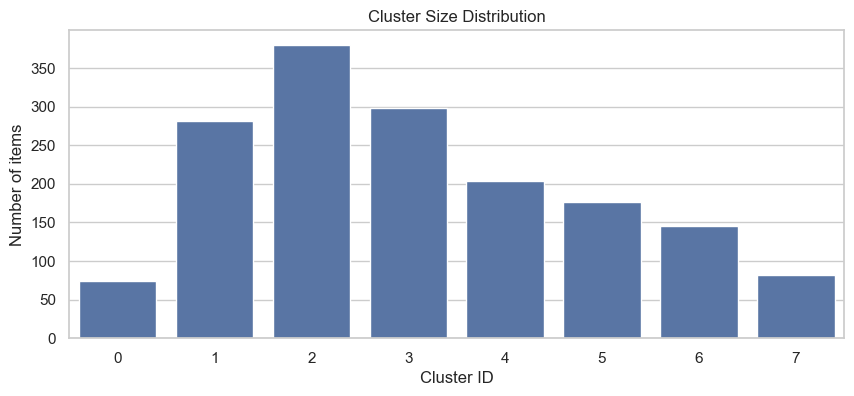

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_relevant.copy()

cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of items")
plt.show()

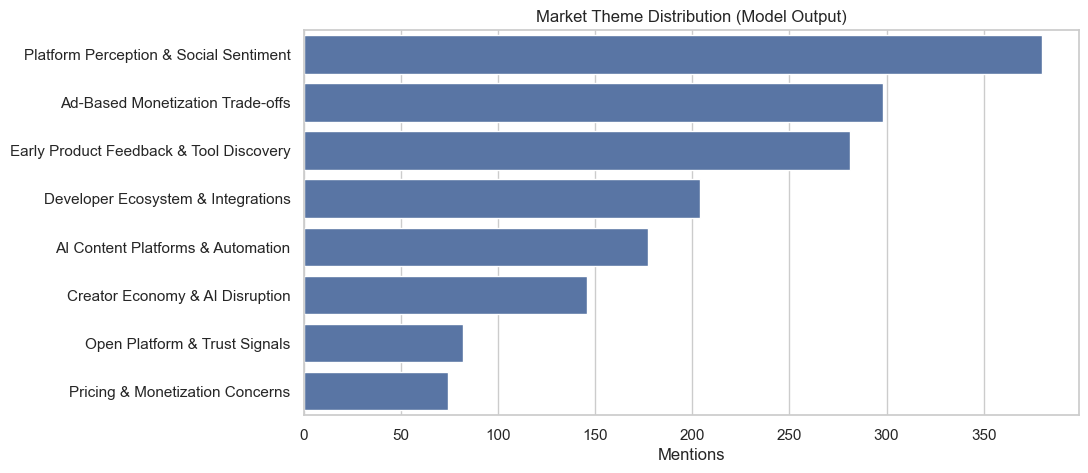

In [30]:
theme_counts = df["market_theme"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(y=theme_counts.index, x=theme_counts.values)
plt.title("Market Theme Distribution (Model Output)")
plt.xlabel("Mentions")
plt.ylabel("")
plt.show()

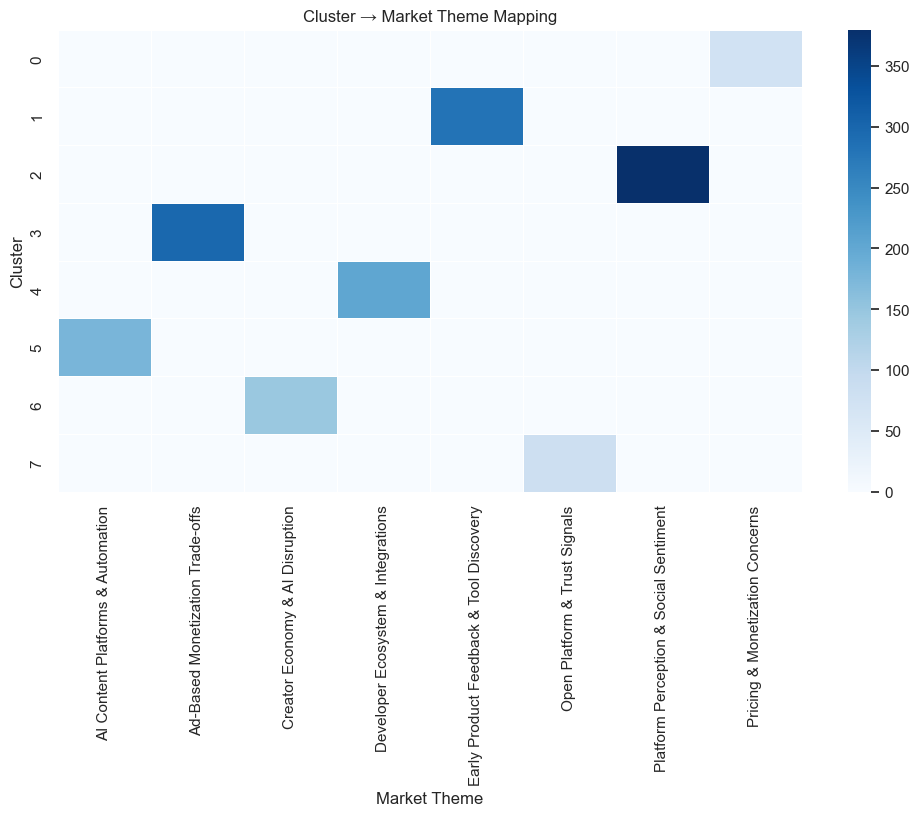

In [31]:
ct = pd.crosstab(df["cluster"], df["market_theme"])

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap="Blues", linewidths=0.5)
plt.title("Cluster → Market Theme Mapping")
plt.xlabel("Market Theme")
plt.ylabel("Cluster")
plt.show()

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

def top_terms_by_theme(df, theme_col="market_theme", text_col="clean_text", top_n=12):
    out = []
    for theme, g in df.groupby(theme_col):
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=8000)
        X = vec.fit_transform(g[text_col].astype(str))
        mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        top_idx = mean_tfidf.argsort()[::-1][:top_n]
        out.append((theme, terms[top_idx].tolist()))
    return pd.DataFrame(out, columns=["market_theme","top_terms"])

top_terms_df = top_terms_by_theme(df)
top_terms_df

,market_theme,top_terms
0,AI Content Platforms & Automation,"[people, open, software, want, like, just, sou..."
1,Ad-Based Monetization Trade-offs,"[ai, built, data, tools, just, https, like, fr..."
2,Creator Economy & AI Disruption,"[app, users, monetization, game, feedback, htt..."
3,Developer Ecosystem & Integrations,"[agent, agents, ai, https, code, github, com, ..."
4,Early Product Feedback & Tool Discovery,"[monetization, platform, like, just, ads, goog..."
5,Open Platform & Trust Signals,"[video, content, youtube, videos, ai, just, mo..."
6,Platform Perception & Social Sentiment,"[just, monetization, like, people, platform, t..."
7,Pricing & Monetization Concerns,"[social, media, social media, platforms, like,..."


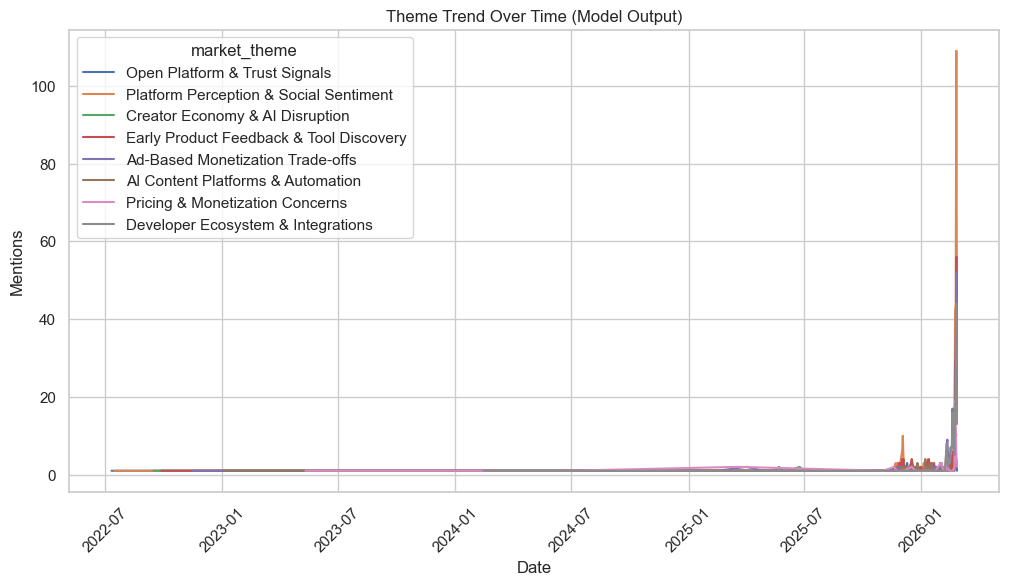

In [33]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["date"] = df["created_at"].dt.date

trend = (
    df.groupby(["date","market_theme"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x="date", y="count", hue="market_theme")
plt.title("Theme Trend Over Time (Model Output)")
plt.xlabel("Date")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.show()

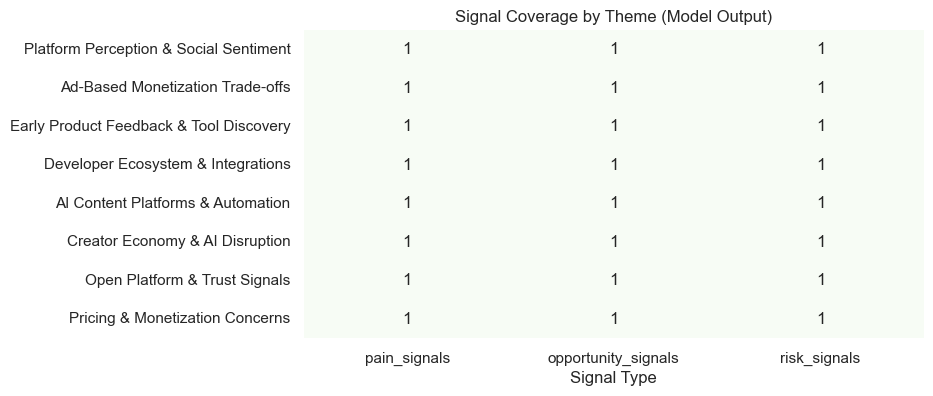

In [35]:
signal_presence = insights_df.copy()

for c in ["pain_signals","opportunity_signals","risk_signals"]:
    signal_presence[c] = signal_presence[c].astype(str).str.len().gt(10).astype(int)

signal_presence = signal_presence.set_index("market_theme")[["pain_signals","opportunity_signals","risk_signals"]]

plt.figure(figsize=(8,4))
sns.heatmap(signal_presence, annot=True, cmap="Greens", cbar=False)
plt.title("Signal Coverage by Theme (Model Output)")
plt.xlabel("Signal Type")
plt.ylabel("")
plt.show()

/var/folders/sy/tv3v7f_x7s9g4tkz_4d624gm0000gn/T/ipykernel_53614/3702720830.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ]].applymap(signal_count)


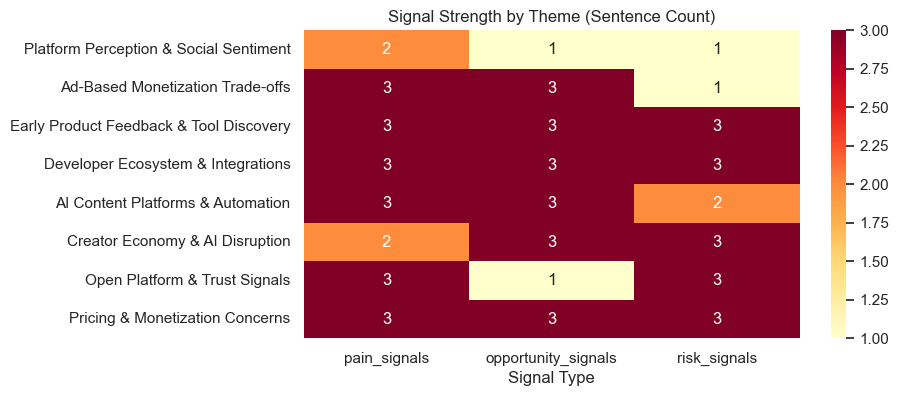

In [36]:
def signal_count(x):
    return len(split_sentences(x)) if isinstance(x, str) else 0

signal_strength = insights_df.set_index("market_theme")[[
    "pain_signals",
    "opportunity_signals",
    "risk_signals"
]].applymap(signal_count)

plt.figure(figsize=(8,4))
sns.heatmap(signal_strength, annot=True, cmap="YlOrRd")
plt.title("Signal Strength by Theme (Sentence Count)")
plt.xlabel("Signal Type")
plt.ylabel("")
plt.show()

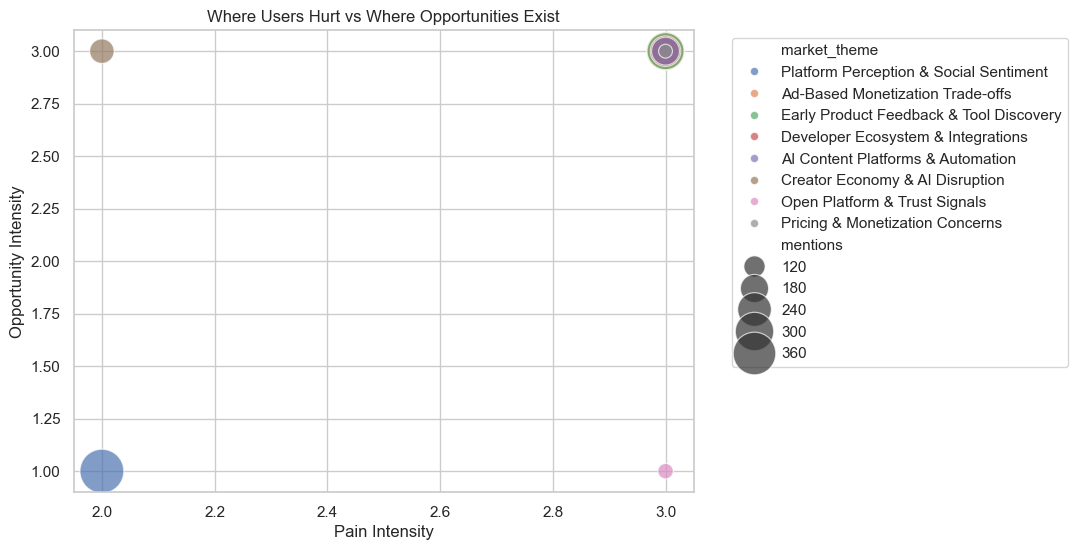

In [37]:
def signal_score(text):
    if not isinstance(text, str):
        return 0
    return len(split_sentences(text))

viz_df = insights_df.copy()
viz_df["pain_score"] = viz_df["pain_signals"].apply(signal_score)
viz_df["opportunity_score"] = viz_df["opportunity_signals"].apply(signal_score)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=viz_df,
    x="pain_score",
    y="opportunity_score",
    size="mentions",
    hue="market_theme",
    sizes=(100, 1000),
    alpha=0.7
)

plt.title("Where Users Hurt vs Where Opportunities Exist")
plt.xlabel("Pain Intensity")
plt.ylabel("Opportunity Intensity")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

/var/folders/sy/tv3v7f_x7s9g4tkz_4d624gm0000gn/T/ipykernel_53614/1356797530.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


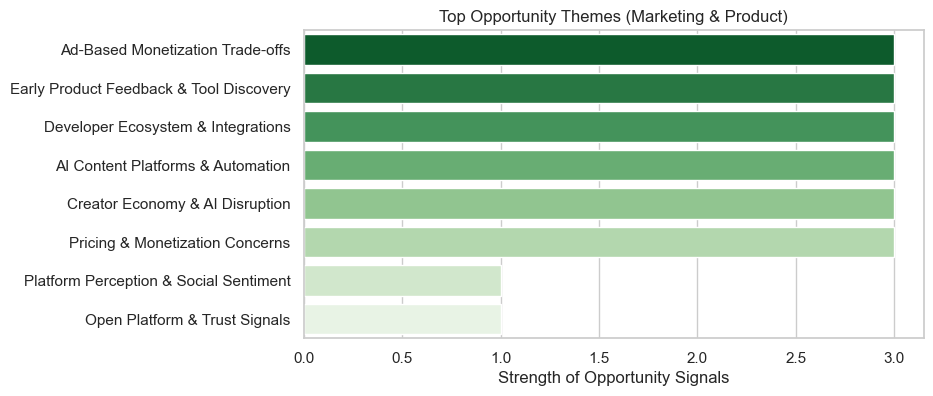

In [38]:
opp_rank = insights_df.copy()
opp_rank["opportunity_score"] = opp_rank["opportunity_signals"].apply(signal_score)

opp_rank = opp_rank.sort_values("opportunity_score", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(
    data=opp_rank,
    y="market_theme",
    x="opportunity_score",
    palette="Greens_r"
)

plt.title("Top Opportunity Themes (Marketing & Product)")
plt.xlabel("Strength of Opportunity Signals")
plt.ylabel("")
plt.show()

In [39]:
def collect_theme_sentences(df, theme, text_col="clean_text"):
    g = df[df["market_theme"] == theme]
    sentences = []
    for t in g[text_col].astype(str):
        sentences.extend(split_sentences(t))
    return list(dict.fromkeys(sentences))  # dedupe
    

In [40]:
SIGNAL_WORDS = [
    "problem","pain","hard","difficult","issue","frustrat",
    "need","gap","missing","lack",
    "opportunity","should","could","better","build","improve",
    "monetization","pricing","workflow","platform","creator"
]

def signal_score(sentence):
    s = sentence.lower()
    return sum(1 for w in SIGNAL_WORDS if w in s)

In [41]:
all_sentences = []

for theme in df_relevant["market_theme"].unique():
    sents = collect_theme_sentences(df_relevant, theme)
    for s in sents:
        all_sentences.append({
            "sentence": s,
            "theme": theme,
            "score": signal_score(s)
        })

sent_df = pd.DataFrame(all_sentences)
sent_df = sent_df[sent_df["score"] > 0]
sent_df = sent_df.sort_values("score", ascending=False)

In [42]:
final_sentences = []
used_themes = set()

for _, row in sent_df.iterrows():
    if len(final_sentences) == 5:
        break
    if row["theme"] not in used_themes:
        final_sentences.append(row["sentence"])
        used_themes.add(row["theme"])

final_sentences

['Hi HN, I build data platforms (Snowflake, dbt, Airflow) and kept seeing the same issue: starting a clean analytics stack is harder than it should be.',
 'The energy could not survive the gap between "this is cool" and "this is how I use it every day." So we stepped back and asked: where does someone feel the pain of missing context multiple times a day, every day, with zero ambiguity?',
 'The app doesn’t need to be a central source of monetization for the creators either, that’s usually the source of all these problems.',
 'So, after building PCs for over 20 years now, and having been tinkering with 3d printing for over 5, I asked myself If I could build something that would suit my needs better.',
 "There is a direct parallel to social media's failure - platforms optimized for what they could do (engagement, monetization) rather than what they should do (serve user long term interests)."]

In [43]:
for i, s in enumerate(final_sentences, start=1):
    print(f"{i}. {s}")

1. Hi HN, I build data platforms (Snowflake, dbt, Airflow) and kept seeing the same issue: starting a clean analytics stack is harder than it should be.
2. The energy could not survive the gap between "this is cool" and "this is how I use it every day." So we stepped back and asked: where does someone feel the pain of missing context multiple times a day, every day, with zero ambiguity?
3. The app doesn’t need to be a central source of monetization for the creators either, that’s usually the source of all these problems.
4. So, after building PCs for over 20 years now, and having been tinkering with 3d printing for over 5, I asked myself If I could build something that would suit my needs better.
5. There is a direct parallel to social media's failure - platforms optimized for what they could do (engagement, monetization) rather than what they should do (serve user long term interests).


In [44]:
import json, joblib

# --- Save scored dataset for RAG ---
# df_relevant already contains market_theme, cluster, etc.
df_relevant.to_csv(SCORED_OUT, index=False)
print("✅ Saved scored dataset:", SCORED_OUT)

# --- Save models/artifacts ---
joblib.dump(kmeans, KMEANS_PATH)
joblib.dump(vectorizer, TFIDF_PATH)
print("✅ Saved models:", KMEANS_PATH, TFIDF_PATH)

# --- Save cluster name map ---
# In your notebook it is called CLUSTER_NAME_MAP
with open(CLUSTER_MAP, "w") as f:
    json.dump(CLUSTER_NAME_MAP, f, indent=2)
print("✅ Saved cluster map:", CLUSTER_MAP)

# --- Save insights / quotes / theme keywords (if they exist) ---
if "insights_df" in globals():
    insights_df.to_csv(INSIGHTS_OUT, index=False)
    print("✅ Saved insights:", INSIGHTS_OUT)

if "quotes_df" in globals():
    quotes_df.to_csv(QUOTES_OUT, index=False)
    print("✅ Saved quotes:", QUOTES_OUT)

if "theme_keywords" in globals():
    theme_keywords.to_csv(THEME_KEYWORDS_OUT, index=False)
    print("✅ Saved theme keywords:", THEME_KEYWORDS_OUT)

# --- Sanity checks for downstream notebooks ---
required_cols = ["clean_text", "market_theme", "keyword", "created_at", "story_title", "url", "objectID"]
missing = [c for c in required_cols if c not in df_relevant.columns]
print("Missing cols:", missing)

assert SCORED_OUT.exists(), "❌ hn_scored_latest.csv not created"
print("✅ Rows saved:", len(df_relevant))

✅ Saved scored dataset: /Users/adarshthakur/Downloads/data/hn_scored_latest.csv
✅ Saved models: /Users/adarshthakur/Downloads/artifacts/kmeans_model.joblib /Users/adarshthakur/Downloads/artifacts/tfidf_vectorizer.joblib
✅ Saved cluster map: /Users/adarshthakur/Downloads/artifacts/cluster_name_map.json
✅ Saved insights: /Users/adarshthakur/Downloads/data/insights_latest.csv
✅ Saved quotes: /Users/adarshthakur/Downloads/data/quotes_latest.csv
✅ Saved theme keywords: /Users/adarshthakur/Downloads/data/theme_keywords_latest.csv
Missing cols: []
✅ Rows saved: 1642
